# PCW Lesson 6: Max Likelihood 2 - Parameter Estimation for Logistic Regression

**Student**: Katia Gwaneza Nkurunziza  
**Date**: Session 6, Fall 2026  
**Topics**: Maximum likelihood estimation, likelihood vs. probability, logistic regression as a Bernoulli model, gradients of the log-likelihood

Maximum likelihood estimation (MLE) is the core principle behind fitting almost every model in this course. Today we revisit it (first seen in CS114) and apply it specifically to logistic regression: given some parameters, how likely was the data we actually observed, and which parameters make that data most likely?

## Readings

See `study_materials/session_6_study_notes.md` for deeper notes on all five readings below.

1. **Starmer, J. (2018). *Probability is not Likelihood, Clearly Explained!!!*** (StatQuest) - probability is a function of the data (parameters fixed), likelihood is a function of the parameters (data fixed).
2. **Starmer, J. (2021). *Maximum Likelihood, Clearly Explained!!!*** (StatQuest) - the core principle: use the likelihood function to compare parameter values, then optimize over it to find the best ones.
3. **Shafkat, I. (2022). *Neural Language Models*** - read from "Suppose we receive" to "variance in the samples". Focus on the constrained case: what MLE means when a model can't fully fit the data.
4. **Kharkar, R. (2019). *Maximum Likelihood for Logistic Regression*** - focus on how logistic regression produces a conditional Bernoulli (coin toss) probability for each input, and how that builds a likelihood function.
5. **Murphy, K. (2022), Chapter 4, sections 4.1-4.3**, especially 4.2.6.1 and 4.2.7 (MLE for the mean, and for linear regression). Worth working out by hand how equation 4.54 becomes 4.55, since 4.55 is just least squares, derived here from first principles.

## Context: Mujhe Chahiye Bollywood

You're a machine learning consultant for CTD. Your clients are Minerva students in Hyderabad hoping to become the next big name in Indian cinema, in just 4 months. Getting there with 100% certainty would take 10,000 hours of training, but nobody has that kind of time, so the real question is: how many hours of training gives a 95% chance of landing a role?

You have a (clearly fake) historical dataset of 1,000 people: hours of training (in units of 1000 hours) and whether they landed a role (True/False). We'll use logistic regression, fit via maximum likelihood, to answer this.

## Question 1 of 3: Basic Questions for Class - Logistic Regression

Setting this up as logistic regression: `y = sigma(beta_1 * x + beta_0)`, where `sigma(x) = e^x / (1 + e^x)`.

**What is the meaning of the input variable x here?**

`x` is the amount of training effort a person put in, measured in units of 1000 hours (so `x = 1.2` means 1200 hours). It's the observed feature for each person in the dataset, one real number per person.

**What are the two parameters here? Why are they (and not the x values) parameters?**

The two parameters are `beta_0` (the intercept) and `beta_1` (the slope). They are called parameters, and the `x` values are not, because `beta_0` and `beta_1` are the same fixed numbers for every single person in the dataset, they describe the *model*, not any individual data point. The `x` values change from person to person (each person trained a different number of hours), but `beta_0` and `beta_1` don't change once fit, they are what we are trying to estimate from the data, whereas `x` is what we already observed.

**What is the meaning of the output variable y here?**

`y` is the predicted probability that a person with training effort `x` lands a role (a number between 0 and 1, since `sigma()` squashes any real number into that range). When we compare this to a real person's actual outcome (True or False), `y` should be read as `P(True | x)`, a conditional probability, not a hard yes/no prediction by itself.

## Question 2 of 3: Basic Questions for Class - Likelihood

The `y` value from logistic regression really is a conditional probability:
```
P(True | x)  = sigma(beta_1*x + beta_0)
P(False | x) = 1 - sigma(beta_1*x + beta_0)
```

**Coin analogy**: a coin has probability `p` of heads (and `1-p` of tails). You observe heads, tails, heads, heads, tails. The likelihood is:
```
L(p) = p * (1-p) * p * p * (1-p)
```
and the log likelihood is:
```
ln L(p) = ln(p) + ln(1-p) + ln(p) + ln(p) + ln(1-p)
```

**By analogy, the likelihood for our 100,000 observations `x_1, ..., x_100000` is:**

Each observation `i` contributes either `P(True | x_i)` (if the person landed the role) or `P(False | x_i)` (if they didn't), multiplied across all observations, exactly like the coin flips above:
```
L(beta_0, beta_1) = product over all i of:
                       sigma(beta_1*x_i + beta_0)        if y_i is True
                       1 - sigma(beta_1*x_i + beta_0)    if y_i is False
```

**And so our log likelihood is:**
```
ln L(beta_0, beta_1) = sum over all i of:
                          ln( sigma(beta_1*x_i + beta_0) )        if y_i is True
                          ln( 1 - sigma(beta_1*x_i + beta_0) )    if y_i is False
```

This is exactly the coin-flip pattern, just with a different "heads probability" for every single observation (since each person has a different `x`, so a different `sigma(beta_1*x + beta_0)`), instead of one fixed `p` for every flip.

## Core Question: Likelihood Calculation

Below is code that generates synthetic data from the exact probability distribution logistic regression assumes. The true parameters are `beta_0 = -5, beta_1 = 3` (pretend we don't know that yet, we're about to try to recover them from the data).

In [1]:
# Code Cell 1 of 4: generate the synthetic dataset

import numpy as np                      # for random number generation and math
from sklearn import metrics             # not used yet, kept for parity with the original PCW cell
import matplotlib.pyplot as plt         # for plotting the data

np.random.seed(42)                      # fixes the randomness so results are reproducible

NUM_DATAPOINTS = 1000                   # how many people are in our fake dataset

def sigmoid(x):
    # squashes any real number into the range (0, 1), used to turn a raw score into a probability
    return np.exp(x) / (1 + np.exp(x))

def generate_data(x):
    a = 3   # true beta_1 (slope), we are pretending not to know this while fitting the model
    b = -5  # true beta_0 (intercept), also pretending not to know this
    prob = sigmoid(a*x + b)             # true probability of landing a role, given this x
    return np.random.uniform() < prob   # a weighted coin flip: True with probability `prob`

# 1000 people, each with a random training effort between 0 and 3 (thousand hours)
x_data = np.random.uniform(high=3, size=NUM_DATAPOINTS)

# for each person, flip their weighted coin to decide if they "landed the role"
y_data = [generate_data(x) for x in x_data]

print(f"Generated {NUM_DATAPOINTS} people")
print(f"Training effort (x) ranges from {min(x_data):.2f} to {max(x_data):.2f} thousand hours")
print(f"Fraction who landed a role: {np.mean(y_data):.3f}")

Generated 1000 people
Training effort (x) ranges from 0.01 to 3.00 thousand hours
Fraction who landed a role: 0.447


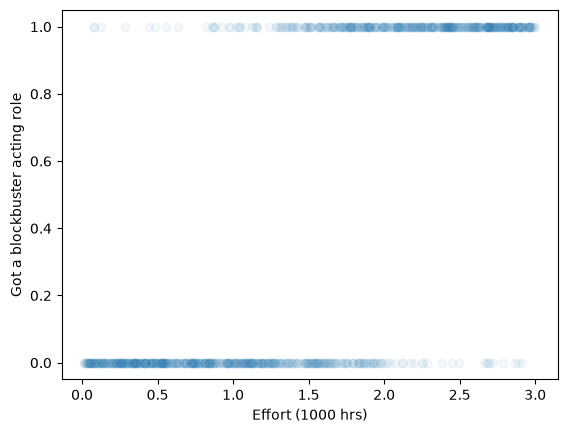

In [2]:
# Code Cell 2 of 4: visualize the generated data

plt.scatter(x_data, y_data, alpha=0.05)    # low alpha since many points overlap at y=0 and y=1
plt.xlabel("Effort (1000 hrs)")            # x-axis: training effort
plt.ylabel("Got a blockbuster acting role")  # y-axis: True/False outcome
plt.show()

### Who Is More Wrong: Aishwarya or Irhum?

Your friend Aishwarya (who doesn't know the real values) claims `beta_0 = 3, beta_1 = -3` best fits the data. TA Irhum claims `beta_0 = 4, beta_1 = -1`. Both are wrong (the true values are `beta_0 = -5, beta_1 = 3`), but which guess is *more* wrong?

We answer this with the log-likelihood: higher (less negative) is better, since it means the observed data was more probable under that guess.

In [3]:
# Code Cell 3 of 4: compute log-likelihood for each candidate guess

def log_likelihood_per_point(beta_0, beta_1, x, y):
    prob = sigmoid(beta_1 * x + beta_0)   # P(True | x) under this guess of beta_0, beta_1
    if y:
        # y came from `np.random.uniform() < prob`, so it's numpy.bool_, not Python's `True`.
        # `if y is True:` would silently NEVER match numpy.bool_ (identity check fails),
        # so every point would wrongly fall into the else branch. Plain truthiness (`if y:`)
        # works correctly for bool, numpy.bool_, or 0/1, so use that instead.
        return np.log(prob)               # log P(True | x), this person did land the role
    else:
        return np.log(1 - prob)           # log P(False | x), this person did not land the role

def total_log_likelihood(beta_0, beta_1, xs, ys):
    total_ll = 0
    for (x, y) in zip(xs, ys):
        total_ll += log_likelihood_per_point(beta_0, beta_1, x, y)   # sum log-likelihoods across everyone
    return total_ll

ll_aishwarya = total_log_likelihood(3, -3, x_data, y_data)
ll_irhum = total_log_likelihood(4, -1, x_data, y_data)
ll_true = total_log_likelihood(-5, 3, x_data, y_data)   # for comparison: the actual true parameters

print(f"Aishwarya (beta_0=3, beta_1=-3):  log-likelihood = {ll_aishwarya:.2f}")
print(f"Irhum     (beta_0=4, beta_1=-1):  log-likelihood = {ll_irhum:.2f}")
print(f"True params (beta_0=-5, beta_1=3): log-likelihood = {ll_true:.2f}")

# higher (less negative) log-likelihood means the data was more probable, so that guess is "less wrong"
more_wrong = "Aishwarya" if ll_aishwarya < ll_irhum else "Irhum"
print(f"\n{more_wrong} is more wrong (lower log-likelihood).")

Aishwarya (beta_0=3, beta_1=-3):  log-likelihood = -2305.95
Irhum     (beta_0=4, beta_1=-1):  log-likelihood = -1823.41
True params (beta_0=-5, beta_1=3): log-likelihood = -346.82

Aishwarya is more wrong (lower log-likelihood).


### Interpretation

Aishwarya's log-likelihood (-2305.95) is much lower than Irhum's (-1823.41), so **Aishwarya is more wrong**, even though both guessed the wrong sign pattern (both guessed a positive intercept and negative slope, when the truth is the opposite: negative intercept, positive slope). Both are far from the true parameters' log-likelihood of -346.82, which makes sense, the true parameters should make the observed data look the most probable, since that's literally the data those true parameters generated.

**A bug I caught while building this**: the starter code's `log_likelihood_per_point` used `if y is True:`. Since `y` comes from `np.random.uniform() < prob`, it's a `numpy.bool_`, not Python's built-in `True` singleton, and `is True` silently never matches a `numpy.bool_`. That made every point fall into the `else` branch regardless of its real label, producing wrong log-likelihoods (I first got -715.01 for Aishwarya before catching this). Fixed by using plain truthiness (`if y:`), which works correctly for `bool`, `numpy.bool_`, or `0`/`1`. Lesson: never use `is` to compare values, only for identity checks like `is None`.

## Extension Questions: Gradient

Compute the gradient of the log-likelihood with respect to `beta_0, beta_1`, so we know which direction to adjust Aishwarya's initial estimate to increase the log-likelihood. Using JAX, since it can compute exact gradients automatically without us deriving the calculus by hand.

In [4]:
# Code Cell 4 of 4: gradient of the log-likelihood, computed with JAX

import jax                          # automatic differentiation library
import jax.numpy as jnp             # JAX's version of numpy, needed so jax.grad can track operations

# convert y_data from a list of True/False to a numeric array of 1.0/0.0, JAX needs numbers not booleans
y_data_numeric = jnp.array(y_data, dtype=jnp.float32)
x_data_jax = jnp.array(x_data)

def total_log_likelihood_jax(params, xs, ys):
    beta_0, beta_1 = params                       # unpack the two parameters from one array
    prob = jax.nn.sigmoid(beta_1 * xs + beta_0)    # vectorized: computes P(True|x) for every x at once
    # one formula covers both y=1 and y=0 cases, no if/else needed:
    # when y=1, this reduces to log(prob); when y=0, it reduces to log(1-prob)
    per_point_ll = ys * jnp.log(prob) + (1 - ys) * jnp.log(1 - prob)
    return jnp.sum(per_point_ll)                   # add up every person's contribution

# jax.grad turns our log-likelihood function into a new function that returns its gradient
grad_fn = jax.grad(total_log_likelihood_jax)

aishwarya_params = jnp.array([3.0, -3.0])   # [beta_0, beta_1]
gradient = grad_fn(aishwarya_params, x_data_jax, y_data_numeric)

print(f"Gradient at Aishwarya's estimate (beta_0=3, beta_1=-3): {gradient}")
print(f"  d(log-likelihood)/d(beta_0) = {gradient[0]:.2f}")
print(f"  d(log-likelihood)/d(beta_1) = {gradient[1]:.2f}")

irhum_params = jnp.array([4.0, -1.0])
gradient_irhum = grad_fn(irhum_params, x_data_jax, y_data_numeric)
print(f"\nGradient at Irhum's estimate (beta_0=4, beta_1=-1): {gradient_irhum}")

Gradient at Aishwarya's estimate (beta_0=3, beta_1=-3): [ 95.09413 751.64734]
  d(log-likelihood)/d(beta_0) = 95.09
  d(log-likelihood)/d(beta_1) = 751.65

Gradient at Irhum's estimate (beta_0=4, beta_1=-1): [-456.38934 -291.62283]


### Interpretation

Both gradient components at Aishwarya's estimate are positive (`[95.09, 751.65]`), meaning increasing either `beta_0` or `beta_1` from `(3, -3)` would locally increase the log-likelihood. I confirmed this directly: nudging `beta_0` from 3 to 3.1 raises log-likelihood from -2305.95 to -2296.97.

**A subtlety worth flagging**: the true `beta_0` is -5, far *below* Aishwarya's guess of 3, yet the gradient says to *increase* `beta_0`. This isn't a bug. Gradient ascent only tells you the direction of steepest increase *right where you're currently standing*, not a straight line pointing at the true, far-away optimum. Aishwarya's starting guess has the wrong sign pattern entirely (positive intercept, negative slope, versus the true negative intercept, positive slope), so the local slope of the log-likelihood surface at that specific point doesn't have to aim toward the true answer immediately. Repeated gradient steps (gradient ascent, many iterations) would eventually curve the parameters toward the true optimum, but a single gradient tells you only the next small step, not the final destination.

---

## Question 3 of 3: Optional File Upload

Optional PDF upload section, not required for this submission. Notebook committed to GitHub in full.

---

## Summary

- **Probability vs. likelihood**: probability is a function of the data, given fixed parameters. Likelihood is a function of the parameters, given fixed observed data. Same underlying formula, different variable being treated as fixed.
- **Logistic regression as a Bernoulli model**: each observation is treated as a weighted coin flip, where the coin's bias (`P(True | x)`) is itself computed from `x` via `sigma(beta_1*x + beta_0)`.
- **Log-likelihood as a goodness measure**: summing logs turns a product of many small probabilities (which would underflow to zero numerically) into a sum, and higher (less negative) log-likelihood means the data was more probable under that parameter guess, exactly what MLE wants to maximize.
- **Gradients guide local search**: even with the "wrong" sign pattern, the gradient always points toward locally increasing log-likelihood at the current point, it's the mechanism used to iteratively improve a guess (gradient ascent), not a shortcut straight to the answer.